In [2]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt


In [3]:
data = pd.read_csv('digit_recognizer_train.csv')

In [4]:
data.head(10)

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
6,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
7,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
9,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [72]:
data = np.array(data)
m,n = data.shape
np.random.shuffle(data)

data_dev = data[0:1000].T # we are transposing it 
Y_dev = data_dev[0]
X_dev = data_dev[1:n]

data_train =  data[1000:m].T
Y_train =  data_train[0]
X_train = data_train[1:n]

X_train = X_train / 255
X_dev = X_dev / 255

In [6]:
data.shape

(42000, 785)

In [7]:
Y_train

array([1, 4, 6, ..., 8, 6, 9], shape=(41000,))

In [73]:
def init_param():
    W1 =np.random.rand(10,784) - 0.5 #generates random values between 0 and 1 for each elemet of the array
    b1 = np.random.rand(10,1) - 0.5
    W2 = np.random.randn(10,10) - 0.5
    b2 = np.random.randn(10,1) - 0.5
    return W1, b1, W2, b2

def ReLU(Z): # activation function
   return np.maximum(0,Z)

def softmax(Z):
    expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
    return expZ / np.sum(expZ, axis=0, keepdims=True)

    
def forward_prop(W1, b1, W2, b2, X):
    Z1 = W1.dot(X)+ b1
    A1 = ReLU(Z1)
    Z2 = W2.dot(A1)+ b2 
    A2 = softmax(Z2)
    return Z1, A1, Z2, A2
    
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max()+1 ))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y
    
def deriv_ReLU(Z):
    return Z > 0
    
    
def backward_prop(Z1, A1, Z2, A2, W2, X, Y):
   m = Y.size
   one_hot_Y = one_hot(Y)
   dZ2 = A2 - one_hot_Y
   dW2 = 1/m * dZ2.dot(A1.T)
   db2 = 1/m * np.sum(dZ2, axis=1, keepdims=True)
   dZ1 =  W2. T . dot(dZ2) * deriv_ReLU(Z1)
   dW1 = 1/m * dZ1.dot(X.T)
   db1 = 1/m * np.sum(dZ1, axis=1, keepdims=True)
   return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1,db1, dW2, db2, alpha):
    W1 = W1 - alpha *dW1
    b1 = b1 -  alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

    

    

In [74]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y)/ Y.size

def gradient_descent( X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_param()
    for i in range(iterations):
        Z1,A1,Z2,A2 = forward_prop(W1,b1,W2,b2,X)
        dW1,db1,dW2, db2 = backward_prop(Z1, A1, Z2, A2,W2,X,Y)
        W1, b1, W2,b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i %50 == 0:
            print("Iteration: ",i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2
        
        
        
    

In [75]:
W1, b1, W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1)

Iteration:  0
[0 8 7 ... 0 7 0] [8 3 1 ... 9 1 5]
Accuracy:  0.07114634146341463
Iteration:  50
[0 7 1 ... 7 1 0] [8 3 1 ... 9 1 5]
Accuracy:  0.2863170731707317
Iteration:  100
[8 7 1 ... 7 1 8] [8 3 1 ... 9 1 5]
Accuracy:  0.41285365853658534
Iteration:  150
[5 3 1 ... 7 1 8] [8 3 1 ... 9 1 5]
Accuracy:  0.5007073170731707
Iteration:  200
[5 3 1 ... 7 1 8] [8 3 1 ... 9 1 5]
Accuracy:  0.6133658536585366
Iteration:  250
[5 3 1 ... 7 1 8] [8 3 1 ... 9 1 5]
Accuracy:  0.6525853658536586
Iteration:  300
[5 3 1 ... 7 1 8] [8 3 1 ... 9 1 5]
Accuracy:  0.6860487804878049
Iteration:  350
[5 3 1 ... 7 1 8] [8 3 1 ... 9 1 5]
Accuracy:  0.7118292682926829
Iteration:  400
[5 3 1 ... 7 1 8] [8 3 1 ... 9 1 5]
Accuracy:  0.7328780487804878
Iteration:  450
[5 3 1 ... 7 1 5] [8 3 1 ... 9 1 5]
Accuracy:  0.7494878048780488


In [76]:
def make_predictions(X, W1, b1, W2, b2):
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    current_image = X_train[:, index, None]
    prediction = make_predictions(X_train[:, index, None], W1, b1, W2, b2)
    label = Y_train[index]
    print("Prediction: ", prediction)
    print("Label: ", label)
    
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

Prediction:  [0]
Label:  0


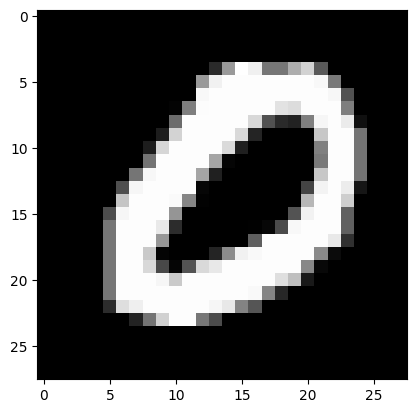

In [80]:
test_prediction(9, W1, b1, W2, b2)

Prediction:  [6]
Label:  6


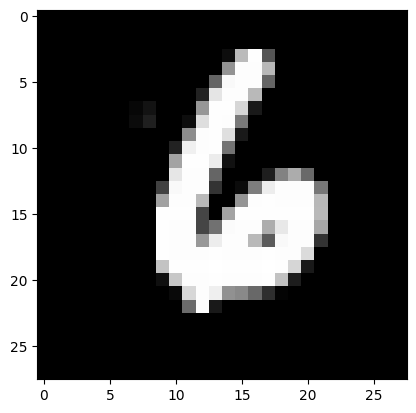

In [81]:
test_prediction(3, W1, b1, W2, b2)

Prediction:  [7]
Label:  7


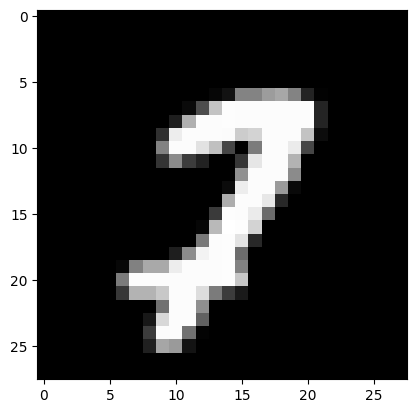

In [82]:
test_prediction(102, W1, b1, W2, b2)

In [79]:
dev_predictions = make_predictions(X_dev, W1, b1, W2, b2)
get_accuracy(dev_predictions, Y_dev)

[1 0 1 1 0 3 0 6 0 0 5 0 3 3 1 7 8 3 5 0 6 7 4 4 3 8 2 2 6 0 1 9 7 3 2 3 0
 7 4 8 7 8 1 8 9 6 5 1 2 9 3 2 1 7 4 9 8 9 3 6 7 3 3 2 0 1 4 3 4 6 7 2 8 2
 0 2 8 4 3 2 6 1 5 6 7 3 8 3 8 5 0 7 3 3 0 6 6 0 3 2 4 5 3 2 7 7 8 3 6 2 4
 1 5 4 7 9 7 1 4 8 7 0 2 3 7 1 5 5 1 4 9 2 5 1 0 7 8 0 5 2 3 4 7 9 8 3 9 2
 7 0 2 3 9 9 5 9 6 7 3 2 5 2 2 7 0 8 7 2 0 8 5 2 8 6 6 9 4 3 7 3 8 6 3 7 2
 3 1 1 4 1 1 7 6 0 1 0 0 2 5 3 9 5 1 2 9 8 1 1 1 2 7 1 2 7 4 0 6 9 1 2 5 8
 0 5 3 7 3 0 3 8 4 1 7 2 4 3 9 9 6 1 5 8 4 5 1 1 3 0 1 5 2 7 4 8 1 2 7 1 2
 6 8 6 2 8 3 2 5 3 0 6 1 0 2 3 1 4 8 1 3 5 7 7 5 1 7 2 8 9 7 1 2 9 5 6 0 0
 5 9 3 1 4 5 2 4 9 8 2 3 9 6 0 9 9 0 3 7 1 8 3 4 5 6 5 2 4 5 4 4 5 1 3 4 4
 5 0 0 1 8 7 3 6 8 7 5 9 0 1 0 1 3 8 6 6 7 8 1 1 6 3 8 0 1 3 2 3 6 3 0 0 0
 2 8 9 4 3 2 0 9 6 5 4 4 7 6 3 0 3 9 1 8 9 2 0 6 0 8 0 7 1 0 2 6 2 9 7 2 2
 6 5 0 3 8 8 1 0 9 3 5 4 0 9 0 2 7 2 4 5 7 3 0 8 8 6 6 9 5 3 0 3 0 1 8 7 2
 7 0 7 8 3 0 3 8 5 9 0 1 7 9 0 4 8 9 9 4 2 5 5 9 8 0 1 2 5 5 4 7 8 1 8 9 9
 6 8 8 1 4 0 1 8 6 4 2 5 

np.float64(0.747)

First layer detects:

curves
loops
horizontal strokes
vertical strokes

Second layer combines them into digits. 
loop + vertical line → maybe 9
two loops → maybe 8

Softmax converts raw scores into probabilities.


overall 
Input image
↓
Detect simple patterns
↓
Combine patterns into shapes
↓
Convert scores into probabilities
↓
Measure error
↓
Adjust weights
↓
Repeat thousands of times